In [1]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torch import optim
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from skimage.color import rgb2lab, lab2rgb
# rgb2lab/lab2rgb fazem a conversao entre os espacos de cor RGB e Lab
import glob

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [2]:
import kagglehub
path = kagglehub.dataset_download("puneet6060/intel-image-classification")
print(path)
# baixa o dataset de paisagens

100%|██████████| 346M/346M [00:08<00:00, 41.5MB/s]

Extracting files...


/root/.cache/kagglehub/datasets/puneet6060/intel-image-classification/versions/2


In [3]:

split = int(len(image_paths) * 0.8)
train_paths = image_paths[:split]
val_paths = image_paths[split:]
# faz a separação dos ddados para treino e para teste
print(len(train_paths), len(val_paths))

14034 imagens encontradas
11227 2807


In [4]:
class ColorizeDataset(Dataset):
    def __init__(self, paths, size=128):
        self.paths = paths
        self.size = size
        # guarda os caminhos das imagens e o tamanho que cada uma vai ser dimensionada

    def __len__(self):
        return len(self.paths)

    def __getitem__(self, ix):
        img = Image.open(self.paths[ix]).convert('RGB').resize((self.size, self.size))
        # abre a imagem, RGB e moddifica o tamanho
        img = np.array(img)
        # converte a imagem PIL para array numpy

        lab = rgb2lab(img).astype('float32')
        # converte de RGB para Lab

        L = lab[:, :, 0] / 100.
        # normaliza para 0-1
        ab = lab[:, :, 1:] / 128.
        # normaliza para [-1,1] targets

        L = torch.from_numpy(L).unsqueeze(0).float()
        # adiciona a dimensao dos canais
        ab = torch.from_numpy(ab).permute(2, 0, 1).float()
        # reordena (2,H,W) formato que a redde espera

        return L, ab

trn_ds = ColorizeDataset(train_paths)
val_ds = ColorizeDataset(val_paths)

trn_dl = DataLoader(trn_ds, batch_size=32, shuffle=True)
val_dl = DataLoader(val_ds, batch_size=32, shuffle=False)

In [5]:
def lab_rgb(L, ab):
    # junta L (entrada real) com ab (previsto ou real) e converte de volta para RGB, para visualizar
    L = L * 100.
    # desfaz a normalizacao do L
    ab = ab * 128.
    # desfaz a normalizacao do ab
    lab = torch.cat([L, ab], dim=0).permute(1, 2, 0).detach().cpu().numpy()
    # junta os 3 canais (L,a,b) e reordena para (H,W,3), formato que o lab2rgb espera
    rgb = lab2rgb(lab.astype('float64'))
    # converte de Lab de volta para RGB
    return np.clip(rgb, 0, 1)
    # garante que os valores fiquem no range valido para exibir

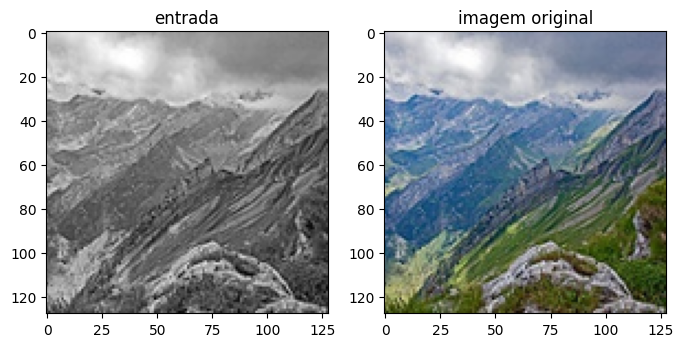

In [6]:
L, ab = trn_ds[0]
rgb = lab_rgb(L, ab)
plt.figure(figsize=(8,4))
plt.subplot(1,2,1)
plt.imshow(L[0], cmap='gray')
plt.title('entrada')
plt.subplot(1,2,2)
plt.imshow(rgb)
plt.title('imagem original')
plt.show()
# visual que ve se a conversao Lab para RGB

In [21]:
class ColorizationNet(nn.Module):
    def __init__(self):
        super().__init__()

        # formato do Conv2d(canais de entrada, canais de saida, tamanho do kernel)

        # reduz a imagem aumenta os canais
        self.encoder = nn.Sequential(
            nn.Conv2d(1, 64, 3,stride=2, padding=1), nn.ReLU(True),# entra a imagem de 1 canal e sai com 64 canais
            nn.Dropout2d(0.3),#ajuda no overfitting
            nn.Conv2d(64, 128, 3, stride=2, padding=1),nn.ReLU(True), #entra com 64 canais e sai com 128 canais
            nn.Dropout2d(0.3),
            nn.Conv2d(128,256, 3, stride=2, padding=1), nn.ReLU(True),
            nn.Dropout2d(0.3),
            nn.Conv2d(256,512, 3,stride=2,padding=1),nn.ReLU(True),
        )
        # expande de volta ao tamanho original, reduzindo os canais
        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(512, 256,2, stride=2), nn.ReLU(True),
            nn.Dropout2d(0.3),
            nn.ConvTranspose2d(256,128, 2,stride=2),nn.ReLU(True),
            nn.Dropout2d(0.3),
            nn.ConvTranspose2d(128,64,2, stride=2), nn.ReLU(True),
            nn.ConvTranspose2d(64,2, 2, stride=2), nn.Tanh(),
        )
        # saida com Tanh porque o alvo fica no intervalo [-1,1]

    def forward(self, x):
        x = self.encoder(x)
        x = self.decoder(x)
        return x


In [22]:
def get_model():
    model = ColorizationNet().to(device)
    optimizer = optim.Adam(model.parameters(), lr=0.001)
    loss_fn = nn.MSELoss()
    return model, optimizer, loss_fn
    # cria o modelo, otimizador e o loss

In [23]:
def train_batch(model, data, optimizer, criterion):
    model.train()
    L, ab = data
    L, ab = L.to(device), ab.to(device)
    # move o batch para o device
    _ab = model(L)
    # previsao do modelo
    optimizer.zero_grad()
    loss = criterion(_ab, ab)
    loss.backward()
    optimizer.step()
    return loss.item()

@torch.no_grad()
def validate_batch(model, data, criterion):
    model.eval()
    L, ab = data
    L, ab = L.to(device), ab.to(device)
    _ab = model(L)
    loss = criterion(_ab, ab)
    return loss.item()
    # validação segue a mesma logica do treino mas sem ajustar pesos

In [24]:
model, optimizer, criterion = get_model()

n_epochs = 20
losses, val_losses = [], []

for epoch in range(n_epochs):
    print(epoch)
    epoch_losses = []
    for bx, data in enumerate(trn_dl):
        loss = train_batch(model, data, optimizer, criterion)
        epoch_losses.append(loss)
    losses.append(np.mean(epoch_losses))
    # treina uma epoca inteira e guarda o loss medio

    epoch_val_losses = []
    for bx, data in enumerate(val_dl):
        loss = validate_batch(model, data, criterion)
        epoch_val_losses.append(loss)
    val_losses.append(np.mean(epoch_val_losses))


    print(f'treino: {losses[-1]}, val: {val_losses[-1]}')

0
treino: 0.01176468646445675, val: 0.008725738084070723
1
treino: 0.009252752288857587, val: 0.008769017686559395
2
treino: 0.00872915660686515, val: 0.00888216055781496
3
treino: 0.008555851659161753, val: 0.008702122823292897
4
treino: 0.00849692782445511, val: 0.008299348389052531
5
treino: 0.008415147958010264, val: 0.008725163447458974
6
treino: 0.008303068932464235, val: 0.008743944540831515
7
treino: 0.00826504305296941, val: 0.008142349368426949
8
treino: 0.00818689039475855, val: 0.008534236424814233
9
treino: 0.008137922354594426, val: 0.008745620932049033
10
treino: 0.008103845975337884, val: 0.008304585422262211
11
treino: 0.008058019339284751, val: 0.008166576264722442
12
treino: 0.008041837435756993, val: 0.008202193670017137
13
treino: 0.007939765891829702, val: 0.008536952986932274
14
treino: 0.007894703910747102, val: 0.00878517333926125
15
treino: 0.007900582171414058, val: 0.00795245689699765
16
treino: 0.007891761697563436, val: 0.00876626630038531
17
treino: 0.007

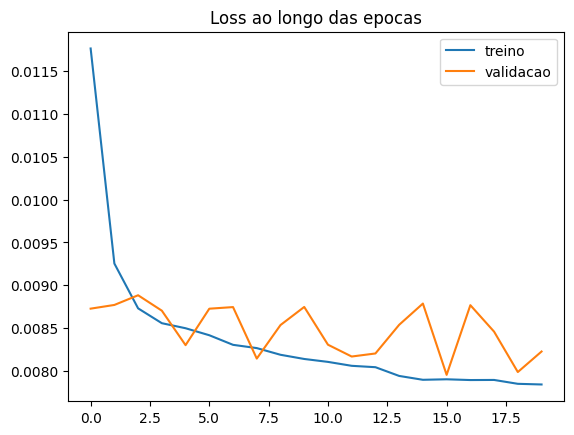

In [25]:
plt.plot(losses, label='treino')
plt.plot(val_losses, label='validacao')
plt.legend()
plt.title('Loss ao longo das epocas')
plt.show()


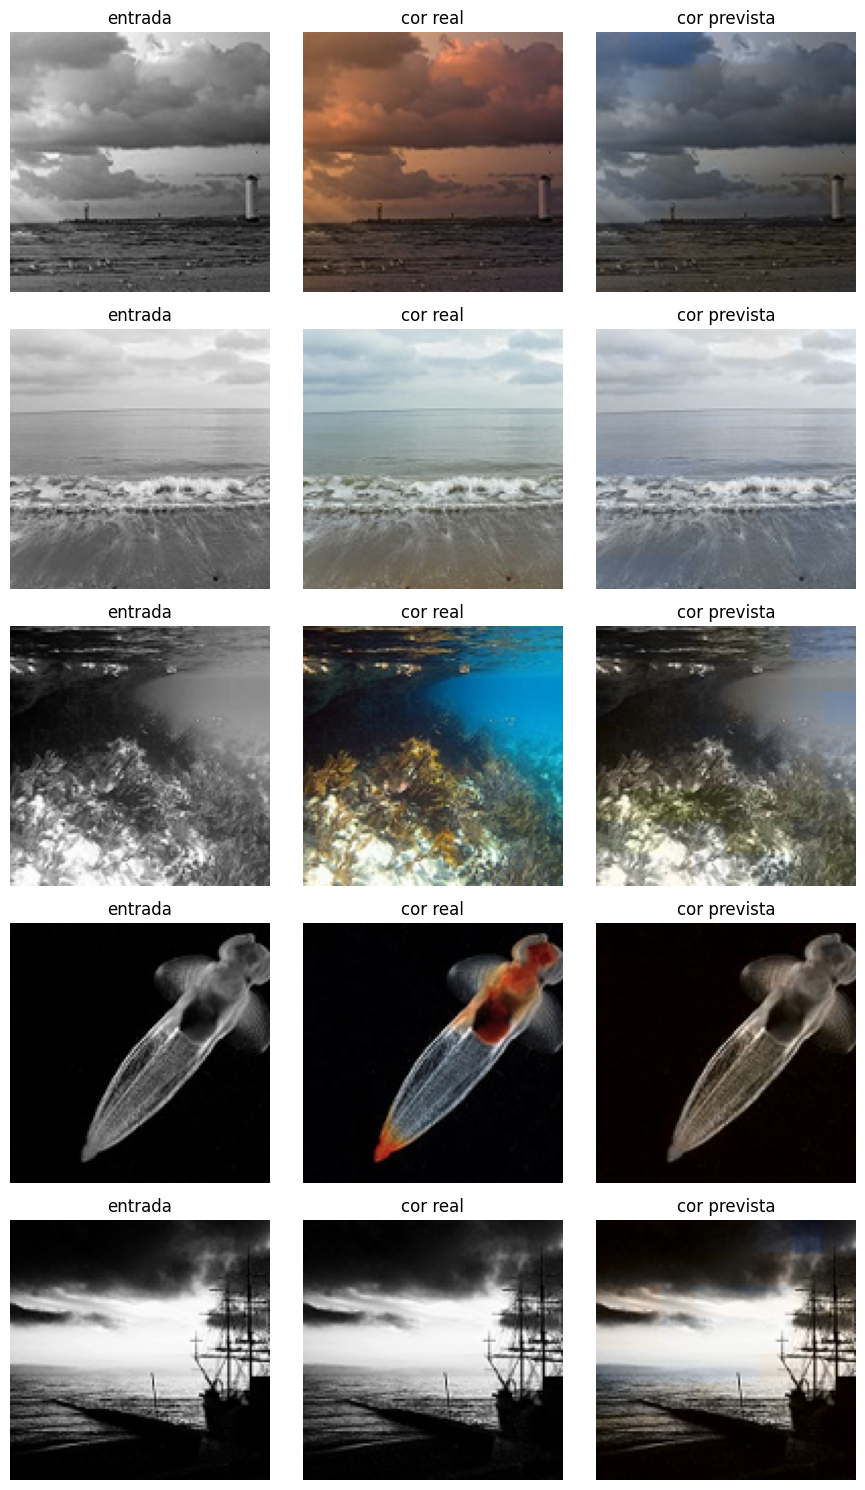

In [26]:
model.eval()
fig, axes = plt.subplots(5, 3, figsize=(9, 15))
# monta uma tabela 3 colunas (cinza real previsto)

for i in range(5):
    L, ab_real = val_ds[i]
    with torch.no_grad():
        ab_pred = model(L.unsqueeze(0).to(device))[0].cpu()
    #coloca uma dimensao a mais no batch, faz a previsao, e depois retorna ao normal

    axes[i,0].imshow(L[0], cmap='gray')
    axes[i,0].set_title('entrada')
    axes[i,1].imshow(lab_rgb(L, ab_real))
    axes[i,1].set_title('cor real')
    axes[i,2].imshow(lab_rgb(L, ab_pred))
    axes[i,2].set_title('cor prevista')
    for j in range(3):
        axes[i,j].axis('off')

plt.tight_layout()
plt.show()
# mostra um exemplo imagem cinza, cor real, e a cor que o modelo pr eviu